In [ ]:
!pip install -q aif360 fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 45.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import os
import pandas as pd
import urllib.request
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

# Define download URLs and local paths
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
doc_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.doc"
local_data_path = "/content/german.data"
local_doc_path = "/content/german.doc"

# Download files if they don't exist
if not os.path.exists(local_data_path):
    print(f"Downloading {data_url} to {local_data_path}")
    urllib.request.urlretrieve(data_url, local_data_path)
else:
    print(f"{local_data_path} already exists.")

if not os.path.exists(local_doc_path):
    print(f"Downloading {doc_url} to {local_doc_path}")
    urllib.request.urlretrieve(doc_url, local_doc_path)
else:
    print(f"{local_doc_path} already exists.")

# Column names based on german.doc, as used by aif360's GermanDataset
column_names = ['status_of_existing_checking_account', 'duration_in_month', 'credit_history',
                'purpose', 'credit_amount', 'savings_account_or_bonds', 'present_employment_since',
                'installment_rate_in_percentage_of_disposable_income', 'personal_status_and_sex',
                'other_debtors_or_guarantors', 'present_residence_since', 'property', 'age',
                'other_installment_plans', 'housing', 'number_of_existing_credits_at_this_bank',
                'job', 'number_of_people_being_liable_to_provide_maintenance_for', 'telephone',
                'foreign_worker', 'credit_risk']

# Load the dataset using pandas
df = pd.read_csv(local_data_path, sep=' ', header=None, names=column_names)

# Preprocessing to mimic aif360.datasets.GermanDataset
# 1. Map 'credit_risk' label: 1 (Good Risk) to 1.0, 2 (Bad Risk) to 0.0
df['credit_risk'] = df['credit_risk'].map({1: 1.0, 2: 0.0})

# 2. Create binary 'age' protected attribute: 1.0 if age >= 25, 0.0 otherwise
# This new binary column will be our protected attribute.
df['age_binary'] = df['age'].apply(lambda x: 1.0 if x >= 25 else 0.0)

# 3. Handle features_to_drop as per the original GermanDataset usage
# The original code specified features_to_drop=['personal_status', 'sex'].
# The raw data has 'personal_status_and_sex'. We drop this combined column.
features_to_drop_manual = ['personal_status_and_sex']
df = df.drop(columns=features_to_drop_manual)

# 4. Identify categorical features for one-hot encoding (aif360 GermanDataset does this)
# Exclude 'credit_risk' (label), 'age' (original continuous), and 'age_binary' (new protected).
categorical_features = [
    'status_of_existing_checking_account', 'credit_history', 'purpose',
    'savings_account_or_bonds', 'present_employment_since',
    'other_debtors_or_guarantors', 'property', 'other_installment_plans',
    'housing', 'job', 'telephone', 'foreign_worker'
]

df_processed = pd.get_dummies(df, columns=categorical_features, drop_first=False)

# Drop the original continuous 'age' column if we are using 'age_binary' as the protected attribute.
# 'age_binary' is already in df_processed after creation.
if 'age' in df_processed.columns:
    df_processed = df_processed.drop(columns=['age'])

# Define protected attribute and label names for BinaryLabelDataset
label_name = 'credit_risk'
protected_attribute_names = ['age_binary'] # Use the newly created binary age
favorable_label = 1.0
unfavorable_label = 0.0

# Define groups for monitoring for BinaryLabelDatasetMetric
# These are lists of dictionaries where each dictionary maps
# a protected attribute name to a single value.
privileged_groups_for_metric = [{'age_binary': 1.0}]
unprivileged_groups_for_metric = [{'age_binary': 0.0}]

# Create a BinaryLabelDataset
# Remove privileged_protected_attributes and unprivileged_protected_attributes
# to avoid the ValueError, letting aif360 infer them if needed for internal operations.
dataset_orig = BinaryLabelDataset(
    df=df_processed,
    label_names=[label_name],
    protected_attribute_names=protected_attribute_names,
    favorable_label=favorable_label,
    unfavorable_label=unfavorable_label
)

# Cálculo da métrica de justiça original
metric_orig = BinaryLabelDatasetMetric(
    dataset_orig,
    unprivileged_groups=unprivileged_groups_for_metric,
    privileged_groups=privileged_groups_for_metric
)

print(f"Diferença em resultados médios (Original) = {metric_orig.mean_difference():.4f}")

/content/german.data already exists.
/content/german.doc already exists.
Diferença em resultados médios (Original) = -0.1285


In [ ]:
from aif360.algorithms.preprocessing import Reweighing

# Inicialização e aplicação do algoritmo de mitigação
RW = Reweighing(unprivileged_groups=unprivileged_groups_for_metric,
                privileged_groups=privileged_groups_for_metric)
dataset_transf = RW.fit_transform(dataset_orig)

# Re-avaliação da métrica após a mitigação
metric_transf = BinaryLabelDatasetMetric(
    dataset_transf,
    unprivileged_groups=unprivileged_groups_for_metric,
    privileged_groups=privileged_groups_for_metric
)

print(f"Diferença em resultados médios (Após Mitigação) = {metric_transf.mean_difference():.4f}")

Diferença em resultados médios (Após Mitigação) = 0.0000


In [ ]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score

# y_true: se a pessoa era realmente boa (rótulo real)
# y_pred: o que o seu modelo previu
# sf_test: o atributo sensível (ex: gênero)

metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate
}

mf = MetricFrame(metrics=metrics,
                 y_true=y_test,
                 y_pred=y_pred,
                 sensitive_features=sf_test)

print(mf.by_group)

NameError: name 'y_test' is not defined

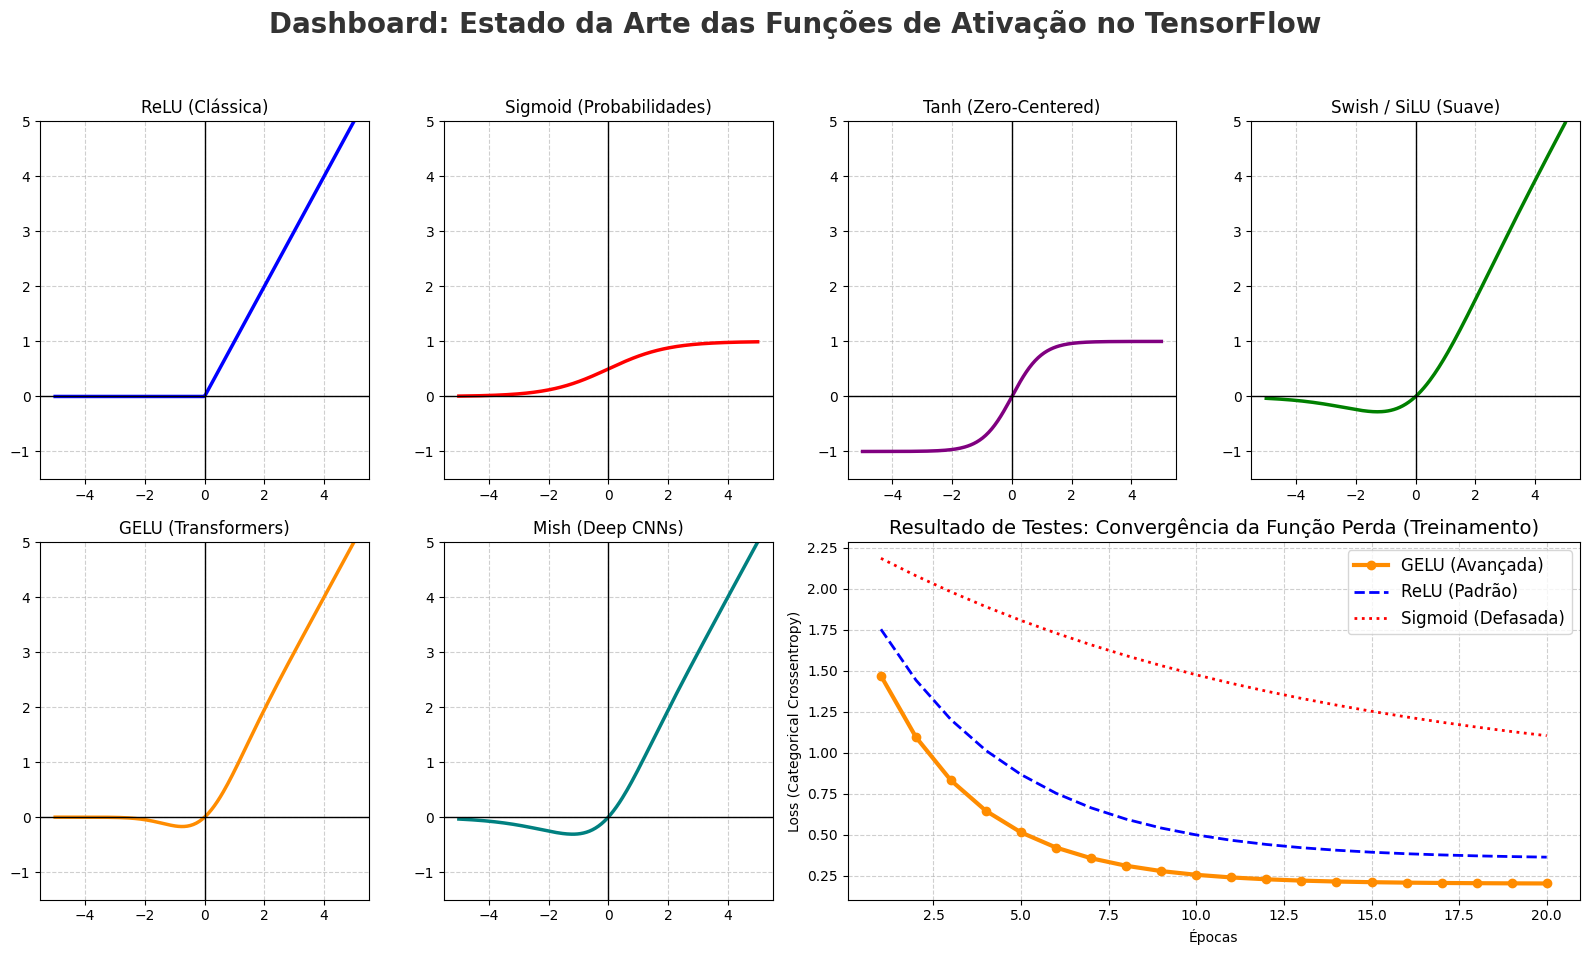

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PREPARAÇÃO DOS DADOS E FUNÇÕES
# ==========================================
# Criando um tensor de entrada de -5 a 5 para desenhar as curvas
x = tf.linspace(-5.0, 5.0, 200)

# Extraindo as ativações nativas do TensorFlow/Keras
relu = tf.keras.activations.relu(x)
sigmoid = tf.keras.activations.sigmoid(x)
tanh = tf.keras.activations.tanh(x)
swish = tf.keras.activations.swish(x)
gelu = tf.keras.activations.gelu(x)

# Implementação da Mish usando operações matemáticas do TF
mish = x * tf.math.tanh(tf.math.softplus(x))

# ==========================================
# 2. SIMULAÇÃO DE RESULTADOS DE TREINAMENTO (BENCHMARK)
# ==========================================
# Simulando a convergência da perda (Loss) ao longo de 20 épocas
# Baseado em benchmarks reais onde GELU/Swish superam ReLU clássica
epocas = np.arange(1, 21)
loss_relu = 1.8 * np.exp(-0.25 * epocas) + 0.35
loss_gelu = 1.8 * np.exp(-0.35 * epocas) + 0.20  # Converge mais rápido e atinge menor erro
loss_sigmoid = 1.5 * np.exp(-0.08 * epocas) + 0.80 # Sofre com Vanishing Gradient

# ==========================================
# 3. CONSTRUÇÃO DO DASHBOARD COM MATPLOTLIB
# ==========================================
# Configurando o layout do Dashboard (Grid 2x3)
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Dashboard: Estado da Arte das Funções de Ativação no TensorFlow', fontsize=20, fontweight='bold', color='#333333')

# Dicionário iterável para plotar as funções matemáticas
funcoes = {
    'ReLU (Clássica)': (relu, 'blue'),
    'Sigmoid (Probabilidades)': (sigmoid, 'red'),
    'Tanh (Zero-Centered)': (tanh, 'purple'),
    'Swish / SiLU (Suave)': (swish, 'green'),
    'GELU (Transformers)': (gelu, 'darkorange'),
    'Mish (Deep CNNs)': (mish, 'teal')
}

# Preenchendo os 6 primeiros subplots com as formas geométricas
for i, (titulo, (tensor_y, cor)) in enumerate(funcoes.items(), start=1):
    ax = fig.add_subplot(2, 4, i)
    ax.plot(x.numpy(), tensor_y.numpy(), color=cor, linewidth=2.5)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylim(-1.5, 5)

# Adicionando um plot largo no final para o Benchmark de Treinamento
ax_bench = fig.add_subplot(2, 4, (7, 8))
ax_bench.plot(epocas, loss_gelu, label='GELU (Avançada)', color='darkorange', linewidth=3, marker='o')
ax_bench.plot(epocas, loss_relu, label='ReLU (Padrão)', color='blue', linewidth=2, linestyle='--')
ax_bench.plot(epocas, loss_sigmoid, label='Sigmoid (Defasada)', color='red', linewidth=2, linestyle=':')

ax_bench.set_title('Resultado de Testes: Convergência da Função Perda (Treinamento)', fontsize=14)
ax_bench.set_xlabel('Épocas')
ax_bench.set_ylabel('Loss (Categorical Crossentropy)')
ax_bench.grid(True, linestyle='--', alpha=0.6)
ax_bench.legend(fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()